In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
train
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [2]:
train

NameError: name 'train' is not defined

In [7]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [9]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [17]:
miss_train = train.isnull().sum()
miss_test = test.isnull().sum()

miss_tra_per = miss_train/len(train) * 100
miss_tes_per = miss_test/len(train) * 100

miss_table = pd.DataFrame({
    "Missing for train":miss_train,
    "Missing for test":miss_test,
    "Missing for % train":miss_tra_per,
    "Missing for % test":miss_tes_per,
})
miss_table.sort_values("Missing for % train",ascending=False)
miss_table.sort_values("Missing for % test",ascending=False)




,Missing for train,Missing for test,Missing for % train,Missing for % test
PoolQC,1453,1456.0,99.520548,99.726027
MiscFeature,1406,1408.0,96.301370,96.438356
Alley,1369,1352.0,93.767123,92.602740
Fence,1179,1169.0,80.753425,80.068493
MasVnrType,872,894.0,59.726027,61.232877
...,...,...,...,...
LandSlope,0,0.0,0.000000,0.000000
LotArea,0,0.0,0.000000,0.000000
LotConfig,0,0.0,0.000000,0.000000
YrSold,0,0.0,0.000000,0.000000


In [20]:
numeric = train.select_dtypes(include=["int64","float64"]).columns.drop("SalePrice")
for col in numeric:
    train[col] = train[col].fillna(train[col]).mean()
    test[col] = test[col].fillna(test[col]).median()

In [23]:
cat_col = train.select_dtypes(include=["object"]).columns

for col in cat_col:
    train[col] = (train[col].fillna(train[col]).mode()[0])
    test[col] = (test[col].fillna(test[col]).mode()[0])

In [24]:
miss_train = train.isnull().sum()
miss_test = test.isnull().sum()

miss_tra_per = miss_train/len(train) * 100
miss_tes_per = miss_test/len(train) * 100

miss_table = pd.DataFrame({
    "Missing for train":miss_train,
    "Missing for test":miss_test,
    "Missing for % train":miss_tra_per,
    "Missing for % test":miss_tes_per,
})
miss_table.sort_values("Missing for % train",ascending=False)
miss_table.sort_values("Missing for % test",ascending=False)

,Missing for train,Missing for test,Missing for % train,Missing for % test
1stFlrSF,0,0.0,0.0,0.0
2ndFlrSF,0,0.0,0.0,0.0
MiscVal,0,0.0,0.0,0.0
MiscFeature,0,0.0,0.0,0.0
MasVnrType,0,0.0,0.0,0.0
...,...,...,...,...
Exterior2nd,0,0.0,0.0,0.0
Exterior1st,0,0.0,0.0,0.0
ExterQual,0,0.0,0.0,0.0
YrSold,0,0.0,0.0,0.0


In [30]:
test


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
1,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
2,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
3,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
4,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
1455,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
1456,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal
1457,2190.0,57.378341,RL,68.580357,9819.161069,Pave,Grvl,Reg,Lvl,AllPub,...,17.064428,1.744345,Ex,MnPrv,Shed,58.167923,6.104181,2007.769705,WD,Normal


In [31]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
1,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
2,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
3,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
4,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
1456,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
1457,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589
1458,730.5,56.89726,RL,70.049958,10516.828082,Pave,Grvl,Reg,Lvl,AllPub,...,2.758904,Gd,MnPrv,Shed,43.489041,6.321918,2007.815753,WD,Normal,180921.19589


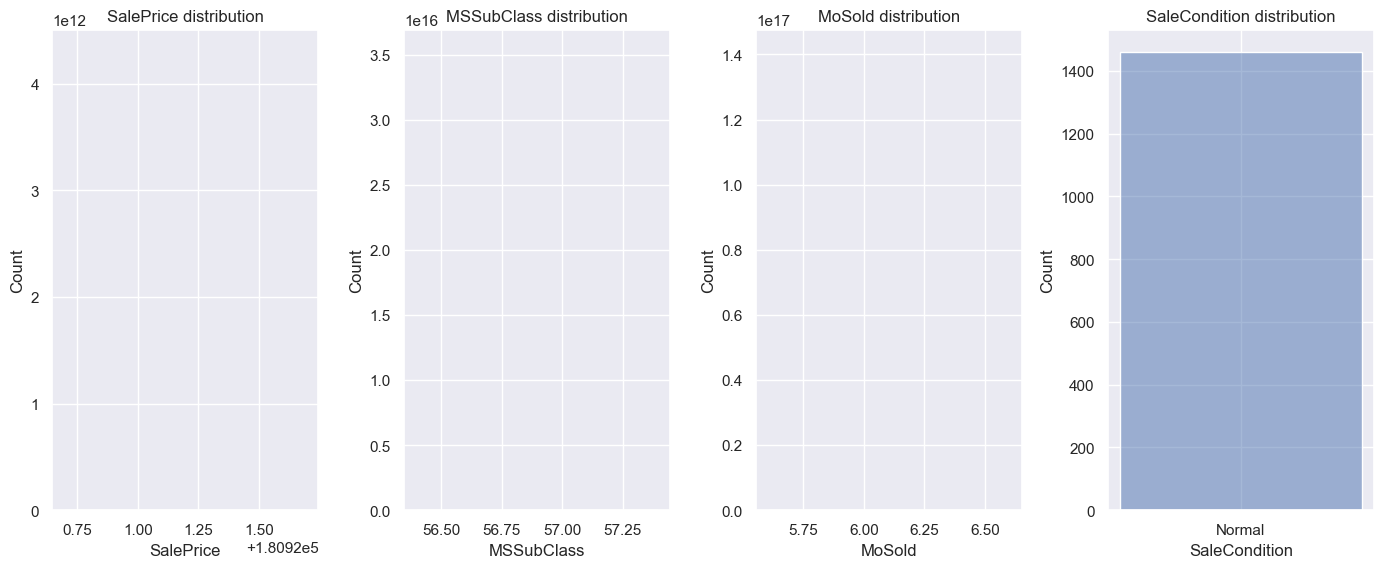

In [42]:
# set seaborn theme
sns.set(style="darkgrid")
fig, axes =plt.subplots(1,4, figsize=(14,6))

sns.histplot(train["SalePrice"], kde=True, bins=10, ax=axes[0])
axes[0].set_title("SalePrice distribution")
sns.histplot(train["MSSubClass"], kde=True, bins=10, ax=axes[1])
axes[1].set_title("MSSubClass distribution")
sns.histplot(test["MoSold"], kde=True, bins=10, ax=axes[2])
axes[2].set_title("MoSold distribution")
sns.histplot(test["SaleCondition"], kde=True, bins=10, ax=axes[3])
axes[3].set_title("SaleCondition distribution")
plt.tight_layout()
plt.show()

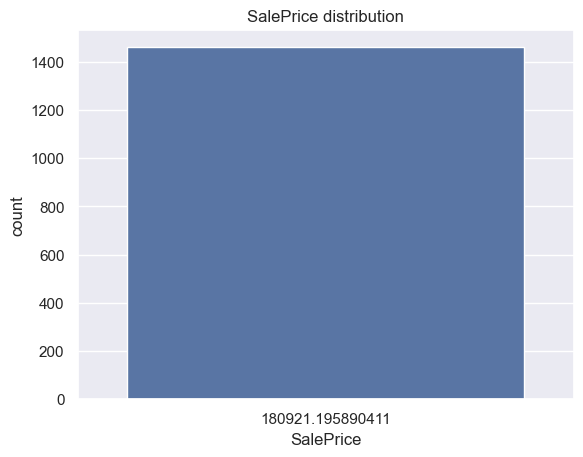

In [40]:
sns.countplot(
    x="SalePrice",
    data=train
)
plt.title("SalePrice distribution")
plt.xlabel("SalePrice")
plt.ylabel("count")

plt.show()

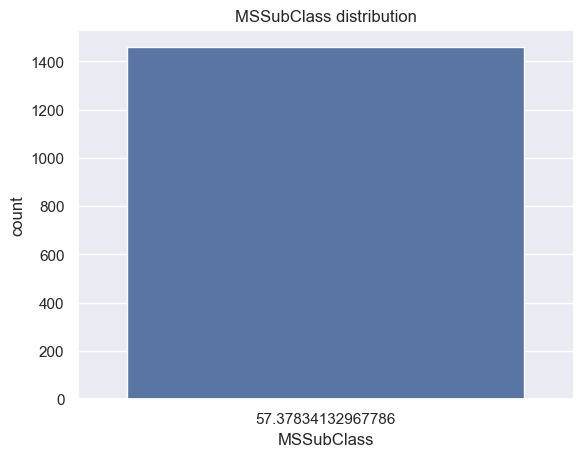

In [41]:
sns.countplot(
    x="MSSubClass",
    data=test
)
plt.title("MSSubClass distribution")
plt.xlabel("MSSubClass")
plt.ylabel("count")

plt.show()

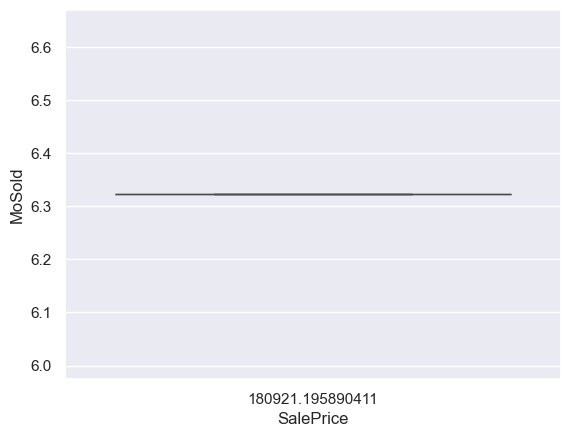

In [43]:
#feature analysis
sns. boxplot(
    
    x="SalePrice",
    y="MoSold",
    data=train
)
plt.show()

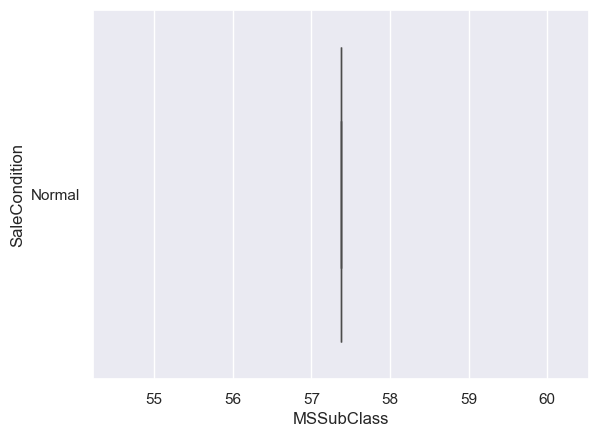

In [44]:
#feature analysis
sns. boxplot(
    
    x="MSSubClass",
    y="SaleCondition",
    data=test
)
plt.show()

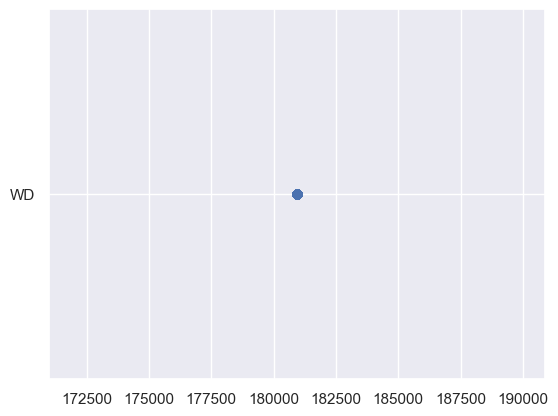

In [50]:
plt.scatter(
    train["SalePrice"],
    train["SaleType"]


    
)

plt.show()

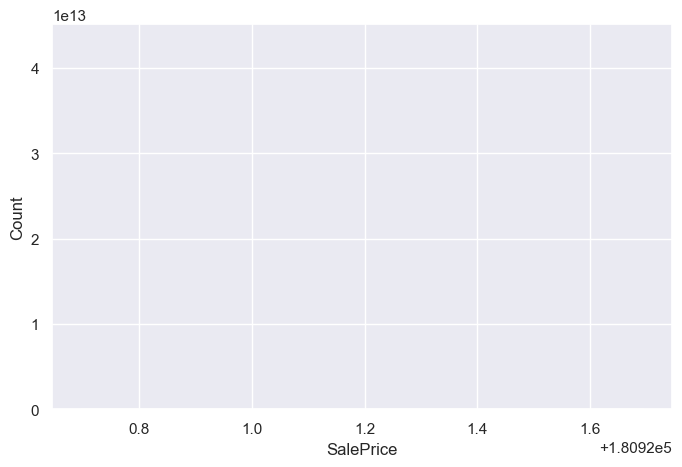

In [51]:
plt.figure(figsize=(8,5))

sns. histplot(
    train["SalePrice"],
    kde=True
)

plt.show()

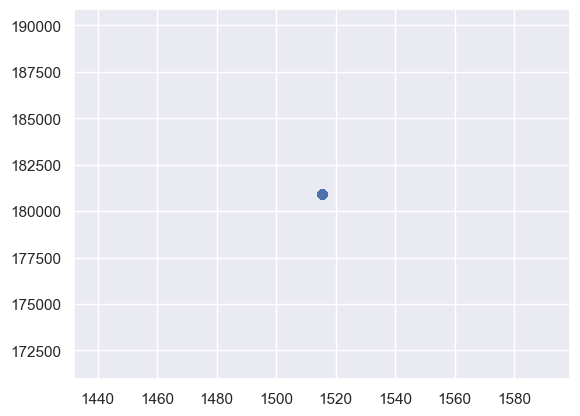

In [52]:
plt.scatter(
    train["GrLivArea"],
    train["SalePrice"]
)

plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


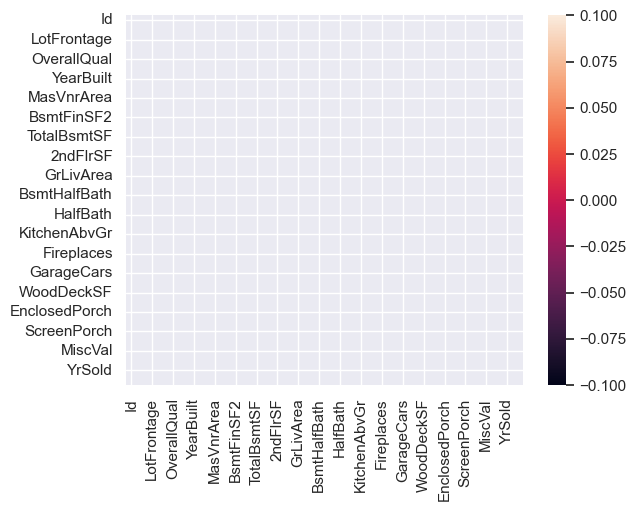

In [53]:
sns.heatmap(
    train.corr(numeric_only=True),
   
    annot=True)
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\User\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


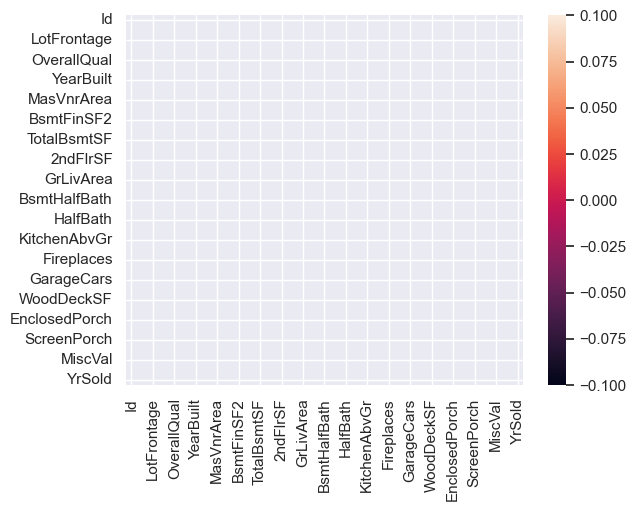

In [54]:
sns. heatmap(
    test.corr(numeric_only=True),
   
    annot=True)
plt.show()

In [1]:
train["TotalBath"]=(train["FullBath"]+ 0.5 * train["HalfBath"])
train["HouseAge"] = (2025- train["YearBuilt"])

train["TotalBath"] = np.log1p(train["TotalBath"])
train["HouseAge"] = np.log1p(train["HouseAge"])

test["MSSubClass"] = np.log1p(test["MSSubClass"])




feature = ["TotalBath", "HouseAge"]
target =["MSSubClass"]

NameError: name 'train' is not defined